## Homework 1

## Step 0: Setup and sector filter
Load the dataset and apply the same cleaning seen in class: keep only active companies, remove ETFs and funds. 
Then filter for your assigned sector 

In [669]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np 

df = pd.read_csv('data/symbol_info_3-25.csv')



# Convert large dollar values into billions.

df["market_cap_b"] = df["market_cap"] / 1e9
df["enterprise_value_b"] = df["enterprise_value"] / 1e9
df["revenue_b"] = df["total_revenue"] / 1e9
df["net_income_b"] = df["net_income"] / 1e9
df["free_cashflow_b"] = df["free_cashflow"] / 1e9

# Convert decimal ratios into percentages where appropriate.

df["profit_margin_pct"] = df["profit_margins"] * 100
df["revenue_growth_pct"] = df["revenue_growth"] * 100
df["earnings_growth_pct"] = df["earnings_growth"] * 100
df["return_on_assets_pct"] = df["return_on_assets"] * 100
df["return_on_equity_pct"] = df["return_on_equity"] * 100
df["debt_to_equity_pct"] = df["debt_to_equity"] * 100

# Replace infinite values with missing values.
df = df.replace([np.inf, -np.inf], np.nan) 


df_filtered = df[
    (df["is_etf"] == 0) &
    (df["is_fund"] == 0) &
    (df["is_actively_trading"] == 1)&
    (df['sector'].isin(['Industrials']))
]

df_filtered.head(10)

,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,...,enterprise_value_b,revenue_b,net_income_b,free_cashflow_b,profit_margin_pct,revenue_growth_pct,earnings_growth_pct,return_on_assets_pct,return_on_equity_pct,debt_to_equity_pct
40,GE,GE Aerospace,Industrials,Aerospace & Defense,217720979456,225490796544,204.130005,203.929993,212.190002,133.990005,...,225.490797,38.701998,6.647000e+00,4.416875e+00,16.940001,14.300001,20.999999,3.271000,27.643999,10415.499878
53,RTX,RTX Corporation,Industrials,Aerospace & Defense,179529449472,215817093120,132.369995,134.470001,135.740005,95.269997,...,215.817093,80.738001,4.774000e+00,5.555375e+00,5.913000,8.500000,4.900000,3.258000,8.125000,6982.099915
65,CAT,"Caterpillar, Inc.",Industrials,Farm & Heavy Construction Machinery,160704643072,193329020928,335.779999,336.250000,418.500000,307.049988,...,193.329021,64.809001,1.079200e+01,5.219875e+00,16.652000,-5.000000,9.600000,9.675000,55.326998,20011.799622
76,UNP,Union Pacific Corporation,Industrials,Railroads,141880508416,172757499904,233.880005,234.789993,258.070007,218.550003,...,172.757500,24.249999,6.747000e+00,4.622875e+00,27.823001,-0.600000,7.800000,9.055001,42.596999,19220.199585
78,HON,Honeywell International Inc.,Industrials,Conglomerates,137061277696,158374887424,210.119995,210.889999,242.770004,189.750000,...,158.374887,38.498001,5.705000e+00,4.256000e+00,14.819001,6.900000,2.800000,7.499000,32.244998,16817.999268
80,BA,Boeing Company (The),Industrials,Aerospace & Defense,134011207680,163292758016,178.110001,172.830002,196.949997,137.029999,...,163.292758,66.517000,1.844674e+10,1.844674e+10,-17.764999,-30.800000,0.000000,-4.269000,0.000000,0.000000
86,DE,Deere & Company,Industrials,Farm & Heavy Construction Machinery,129469915136,188582084608,472.429993,477.019989,515.049988,340.200012,...,188.582085,47.855002,6.218000e+00,1.190125e+00,12.993000,-30.199999,-48.800001,4.960000,27.745000,28967.401123
97,ETN,"Eaton Corporation, PLC",Industrials,Specialty Industrial Machinery,115779682304,123760476160,295.440002,295.529999,379.989990,255.649994,...,123.760476,24.878000,3.794000e+00,2.847125e+00,15.250000,4.600000,4.300000,7.605000,20.201999,5388.299942
102,LMT,Lockheed Martin Corporation,Industrials,Aerospace & Defense,109863878656,122434183168,439.700012,466.739990,618.950012,419.700012,...,122.434183,71.042998,5.336000e+00,5.397625e+00,7.511000,-1.300000,-70.700002,8.306000,81.044996,33819.699097
115,UPS,"United Parcel Service, Inc.",Industrials,Integrated Freight & Logistics,99144261632,117674188800,115.099998,116.980003,157.990005,109.400002,...,117.674189,91.069997,5.782000e+00,4.794625e+00,6.349000,1.500000,7.000000,7.106000,33.955002,15321.000671


In [670]:
describe = pd.DataFrame({
    "column": df_filtered.columns,
    "dtype": df_filtered.dtypes.astype(str).values,
    "missing_values": df_filtered.isna().sum().values,
    "missing_pct": (df_filtered.isna().mean().values * 100).round(2)
})

print(describe)

                  column    dtype  missing_values  missing_pct
0                 symbol      str               0          0.0
1           company_name      str               0          0.0
2                 sector      str               0          0.0
3               industry      str               0          0.0
4             market_cap    int64               0          0.0
5       enterprise_value   uint64               0          0.0
6          current_price  float64               0          0.0
7         previous_close  float64               0          0.0
8    fifty_two_week_high  float64               0          0.0
9     fifty_two_week_low  float64               0          0.0
10     fifty_day_average  float64               0          0.0
11   two_hundred_day_avg  float64               0          0.0
12                  beta  float64               0          0.0
13           pe_trailing  float64               0          0.0
14            pe_forward  float64               0      

## Step 1: Market Capitalization Distribution 
Plot a histogram of market_cap for your sector. Add two vertical lines: one for the mean, one for the median.
Both must be annotated with their value

In [671]:
# show numbers as billions with one decimal.

def billions_formatter(x, pos):
    return f"{x:,.0f}B"

# show percentages with no decimal places.

def pct_formatter(x, pos):
    return f"{x:.0f}%"

# remove unnecessary chart borders.

def clean_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

# useful to annotate bars in a horizontal bar chart.
def annotate_hbar(ax, fmt="{:.1f}"):
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(width, y, "  " + fmt.format(width), va="center", fontsize=10)

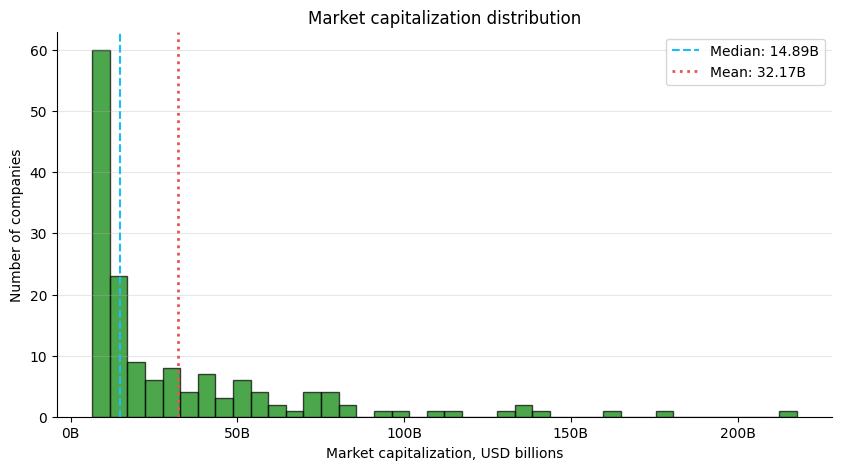

In [672]:
#creates a new independent pandas object (a Series) containing only the "market_cap_b" column, with NaN values removed.

market_cap_b = df_filtered["market_cap_b"].dropna().copy() 


fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    market_cap_b,         
                         # market_cap contains the market capitalization values.

    bins=40,             # Number of intervals used to split the data.
                         # More bins = more detail, but the chart may become noisy.
                         # Fewer bins = smoother chart, but less detail.

    color="green",     # Fill color of the bars.
                         
                         

    edgecolor="black",   # Color of the border around each bar.
                        

    alpha=0.70           # Transparency level of the bars.
                         # 1.0 means fully opaque.
                         # 0.0 means fully transparent.
                         # 0.70 keeps the color strong but slightly softer.
)


# Compute the median and the mean of the variable market_cap 

median_value = market_cap_b.median()
mean_value = market_cap_b.mean()

#Set the style of the median and mean lines displayed on the graph.
ax.axvline(median_value, color="#18BEF5", linestyle="--", linewidth=1.5, label=f"Median: {median_value:,.2f}B")
ax.axvline(mean_value, color="#E45656", linestyle=":", linewidth=2, label=f"Mean: {mean_value:,.2f}B")

ax.set_title("Market capitalization distribution")
ax.set_xlabel("Market capitalization, USD billions")
ax.set_ylabel("Number of companies")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="y", alpha=0.30)
ax.legend()
clean_spines(ax)

plt.show()





## Step 2: Outlier Direction 
Plot a boxplot of market_cap. If needed remove outliers. Use the cleaned dataset from this point forward.

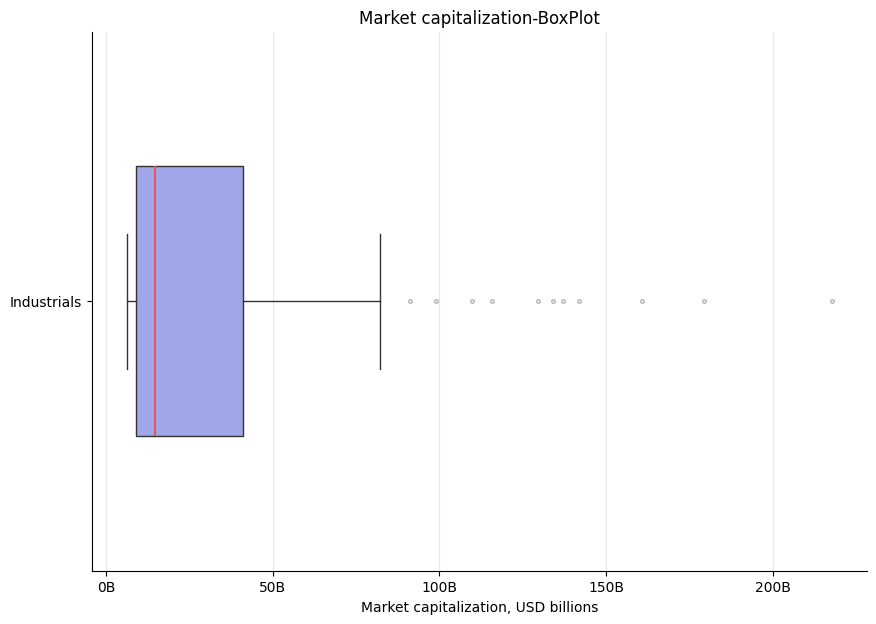

In [673]:

market_cap_b = df_filtered["market_cap_b"].dropna().copy()

fig, ax = plt.subplots(figsize=(10, 7))

ax.boxplot(
    market_cap_b, # list of arrays 

    vert=False, # Draw boxes horizontally instead of vertically.

    patch_artist=True, # Allow the boxes to be filled with color.

    tick_labels = ['Industrials'],

    widths=0.5, 

    boxprops={"facecolor": "#A0A7E8", "edgecolor": "#333333"}, #  facecolor controls the fill color;
                                                                    # edgecolor controls the border color.
    medianprops={"color": "#E4565D", "linewidth":1.5}, # set the median style

    whiskerprops={"color": "#333333"}, # set the whiskers style

    capprops={"color": "#333333"},   # Style of the caps at the end of each whisker.

    flierprops={"marker": "o", "markersize":2.5, "alpha": 0.30} # style of the outlier points 
)


ax.set_title("Market capitalization-BoxPlot")
ax.set_xlabel("Market capitalization, USD billions")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="x", alpha=0.30)
clean_spines(ax)

plt.show()



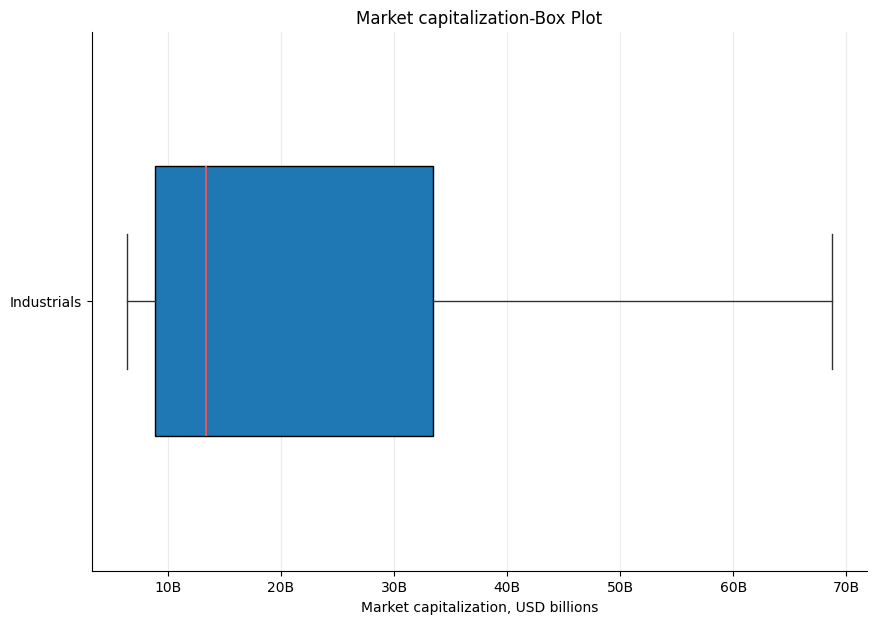

In [674]:
#we remove outliers using the Interquartile Range (IQR) rule:

Q1 = df_filtered["market_cap_b"].quantile(0.25)
Q3 = df_filtered["market_cap_b"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR 



df_clean = df_filtered[(df_filtered["market_cap_b"] >= lower)&
                      (df_filtered["market_cap_b"]<= upper)
                        ]


fig, ax = plt.subplots(figsize=(10, 7))

ax.boxplot(

    df_clean["market_cap_b"].dropna(),

    vert=False,

    patch_artist=True,

    tick_labels=["Industrials"],

    widths=0.5,

    medianprops={"color": "#E4565D", "linewidth":1.5},

    whiskerprops={"color": "#333333"},

    capprops={"color": "#333333"},

    showfliers=False # Removes outlier points (fliers) from the visualization.
                    # I set this condition because the outilers have been removed 
   
)

ax.set_title("Market capitalization-Box Plot")
ax.set_xlabel("Market capitalization, USD billions")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

plt.show()



## Step 3: Industry comparison: Four metrics 
Create a single figure with 4 subplots: Each subplot is a horizontal bar chart showing the mean value per industry for one of the following metrics:
+  market_cap 
+  total_revenue 
+ profit_margins 
+  beta 


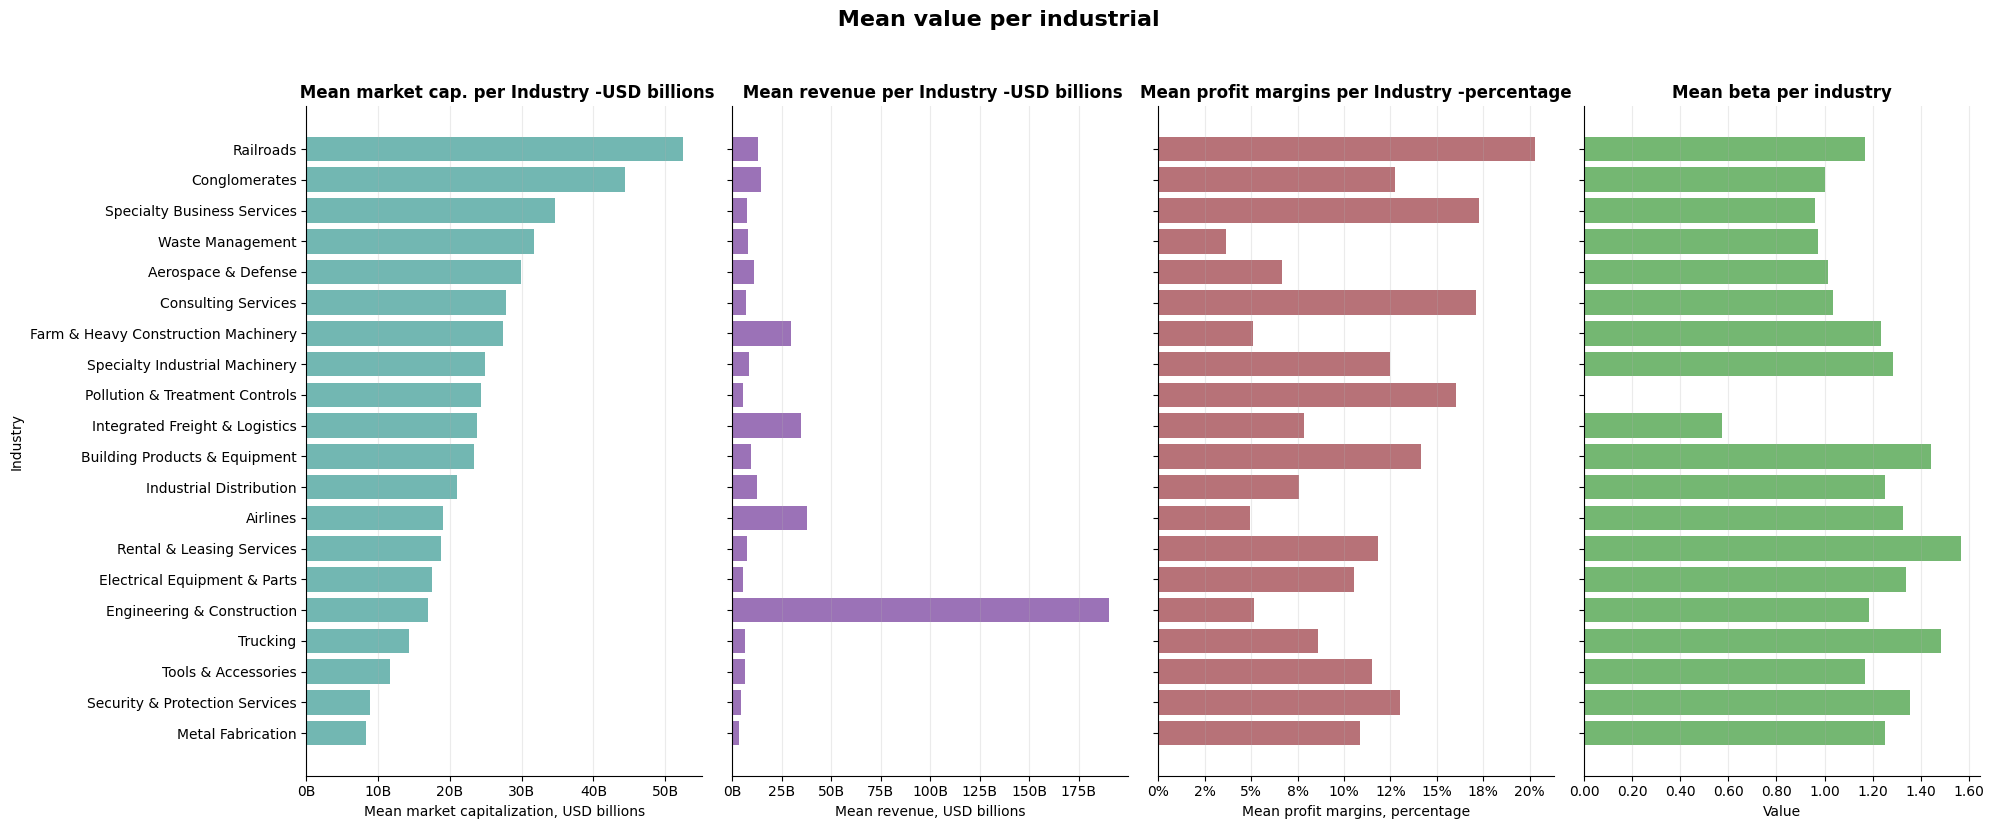

In [675]:

grouped = df_clean[["industry", "market_cap_b", "revenue_b", "profit_margin_pct", "beta"]].groupby("industry").mean()

grouped = grouped.sort_values("market_cap_b", ascending=True)

# Create one figure with four columns.
fig, ax = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(20, 8),
    sharey=True
)

#Set the axis
ax_cap = ax[0]
ax_rev = ax[1]
ax_prof = ax[2]
ax_beta = ax[3]



# 1. Market Capitalization 
ax_cap.barh(
    grouped.index, # Index is the variable Industry 
    grouped["market_cap_b"],
    color="#72B7B2"
)

ax_cap.set_title(" Mean market cap. per Industry -USD billions",fontweight="bold")
ax_cap.set_xlabel("Mean market capitalization, USD billions")
ax_cap.set_ylabel("Industry")
ax_cap.grid(axis="x", alpha=0.25)
ax_cap.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
clean_spines(ax_cap)

# 2. Revenue
ax_rev.barh(
    grouped.index,
    grouped["revenue_b"],
    color = "#9B72B7"
)

ax_rev.set_title(" Mean revenue per Industry -USD billions",fontweight="bold")
ax_rev.set_xlabel("Mean revenue, USD billions")
ax_rev.grid(axis="x", alpha=0.25)
ax_rev.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
clean_spines(ax_rev)

# 3. Profit Margins
ax_prof.barh(grouped.index,
            grouped["profit_margin_pct"],
            color ="#B77278"
)
ax_prof.set_title("Mean profit margins per Industry -percentage",fontweight="bold")
ax_prof.set_xlabel("Mean profit margins, percentage")
ax_prof.grid(axis="x", alpha=0.25)
ax_prof.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
clean_spines(ax_prof)

# 4. Beta
ax_beta.barh(
    grouped.index,
    grouped["beta"],
    color ="#74B772"
)

ax_beta.set_title("Mean beta per industry",fontweight="bold")
ax_beta.set_xlabel("Value")
ax_beta.grid(axis="x", alpha=0.25)
ax_beta.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}"))
clean_spines(ax_beta)

fig.suptitle(
    " Mean value per industrial",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()
 

## Step 4: Industry dispersion
Create 4 boxplots, one per metric(market_cap,total_revenue,profit_margins,beta). Each boxplot must show the full distribution broken down per industry, not just the mean. 

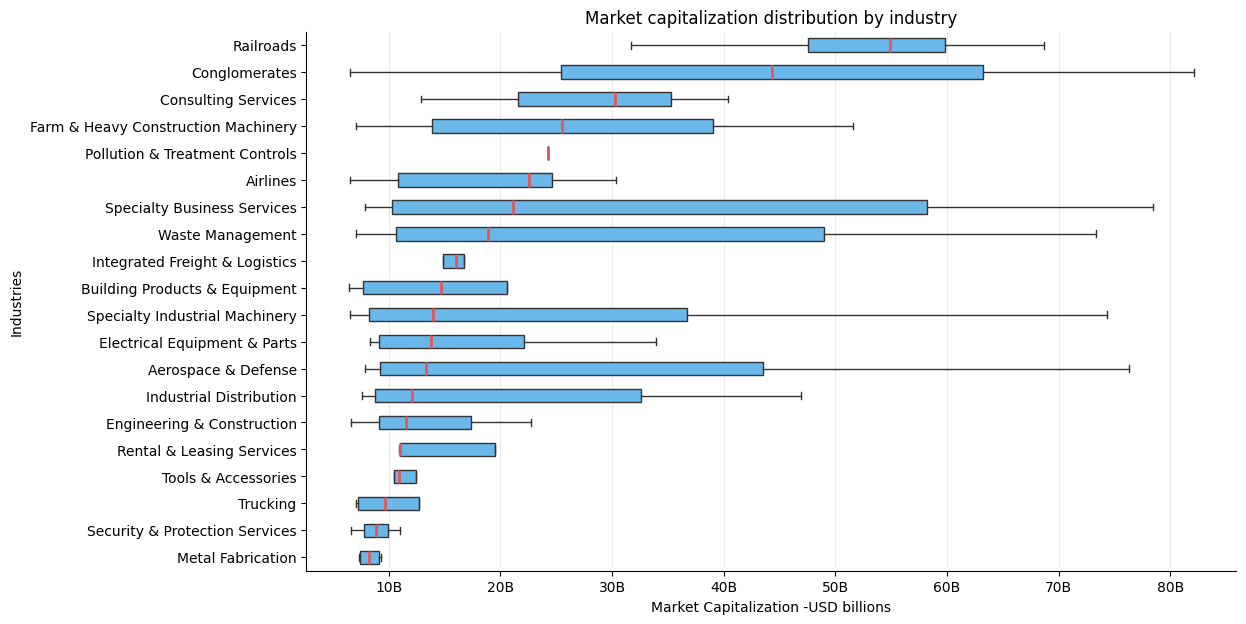

In [676]:
box_df = df_clean[["market_cap_b","industry"]].copy()

# Order industries by median profitability.
industry_order = (
    box_df.groupby("industry")["market_cap_b"]
    .median()
    .sort_values(ascending=True)
    .index
)

  # Create a  list of arrays: one array of profit market capitalizaton  values per industry.
box_data = [
    box_df.loc[box_df["industry"] == industry, "market_cap_b"].values
    for industry in industry_order
]


fig, ax = plt.subplots(figsize=(12, 7))

# Create the horizontal box plot.
# The box summarizes the distribution of market_cap  within each industry.
ax.boxplot(
    box_data,
    tick_labels=industry_order,
    vert=False,  # Draw boxes horizontally instead of vertically.
    patch_artist=True, # Allow the boxes to be filled with color.
    boxprops={"facecolor": "#6AB7EA", "edgecolor": "#333333"}, # - facecolor controls the fill color and edgecolor controls the border color.
    medianprops={"color": "#E45756", "linewidth": 2},# set up the median style inside the box
    whiskerprops={"color": "#333333"},  # Style of the whiskers
    capprops={"color": "#333333"}, # Style of the caps at the end of each whisker.
    showfliers=False # I removed the outliers regarding the variable market_cap_b 

    
)


ax.set_title("Market capitalization distribution by industry")
ax.set_xlabel("Market Capitalization -USD billions")
ax.set_ylabel("Industries")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter)) 
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

plt.show()

the lower bound is: -23
the upper bound is: 47


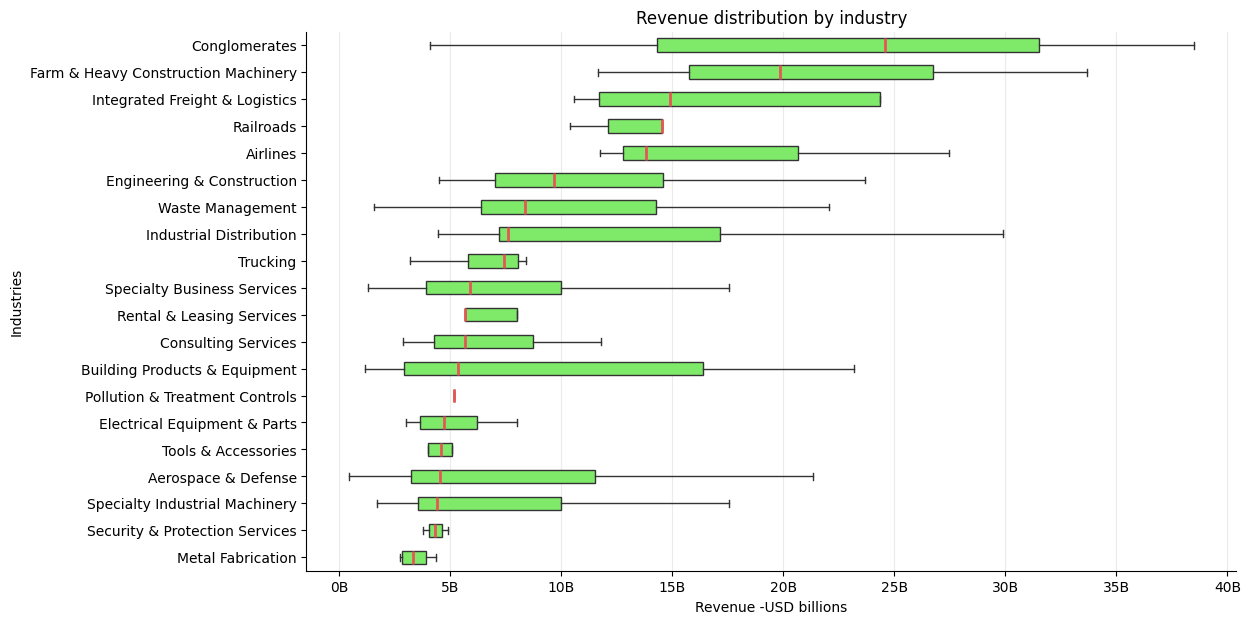

In [677]:
# I remove the outliers from the variable revenue_b in order to avoid 
Q1 = df["revenue_b"].quantile(0.25)
Q3 = df["revenue_b"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR 

print(f"the lower bound is: {lower:.0f}")
print(f"the upper bound is: {upper:.0f}")

box_df= df_filtered[(df_filtered["revenue_b"] >= lower)&
                (df_filtered["revenue_b"]<= upper)
            ].dropna(subset=["industry", "revenue_b"]).copy()

industry_order = (
    box_df.groupby("industry")["revenue_b"]
    .median()
    .sort_values(ascending=True)
    .index
)

box_data = [
    box_df.loc[box_df["industry"] == industry, "revenue_b"].values
    for industry in industry_order
]


fig, ax = plt.subplots(figsize=(12, 7))


ax.boxplot(
    box_data,
    tick_labels=industry_order,
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": "#7FEA6A", "edgecolor": "#333333"},
    medianprops={"color": "#E45756", "linewidth": 2},
    whiskerprops={"color": "#333333"},
    capprops={"color": "#333333"},
    showfliers=False
    
)


ax.set_title("Revenue distribution by industry")
ax.set_xlabel("Revenue -USD billions")
ax.set_ylabel("Industries")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

plt.show()


the lower bound is: -9
the upper bound is: 29


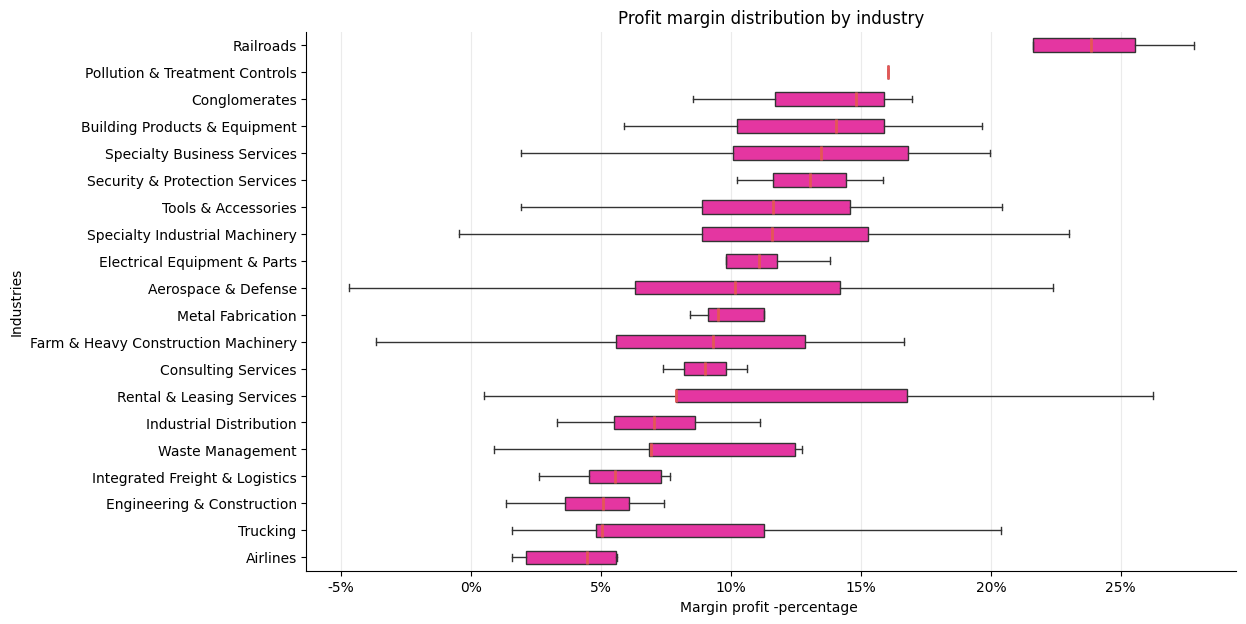

In [678]:
Q1 = df_filtered["profit_margin_pct"].quantile(0.25)
Q3 = df_filtered["profit_margin_pct"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR 

print(f"the lower bound is: {lower:.0f}")
print(f"the upper bound is: {upper:.0f}")

box_df = df_filtered[(df_filtered["profit_margin_pct"] >= lower)&
                (df_filtered["profit_margin_pct"]<= upper)
            ].dropna(subset=["industry", "profit_margin_pct"]).copy()




industry_order = (
    box_df.groupby("industry")["profit_margin_pct"]
    .median()
    .sort_values(ascending=True)
    .index
)


box_data = [
    box_df.loc[box_df["industry"] == industry, "profit_margin_pct"].values
    for industry in industry_order
]


fig, ax = plt.subplots(figsize=(12, 7))


ax.boxplot(
    box_data,
    tick_labels=industry_order,
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": "#E436A1", "edgecolor": "#333333"},
    medianprops={"color": "#E45756", "linewidth": 2},
    whiskerprops={"color": "#333333"},   
    capprops={"color": "#333333"},
    showfliers=False
)


ax.set_title("Profit margin distribution by industry")
ax.set_xlabel("Margin profit -percentage ")
ax.set_ylabel("Industries")
ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

plt.show()

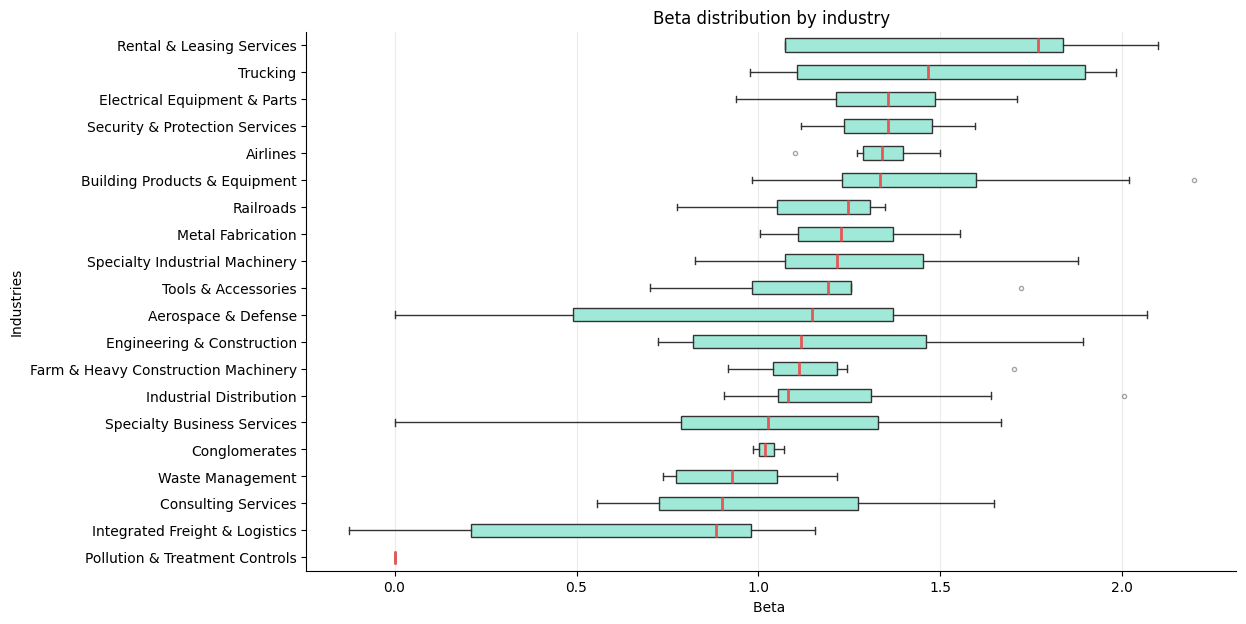

In [679]:

box_df = df_filtered.dropna(subset=["industry", "beta"]).copy()
industry_order = (
    box_df.groupby("industry")["beta"]
    .median()
    .sort_values(ascending=True)
    .index
)

box_data =[
    box_df.loc[box_df["industry"] == industry, "beta"].values
    for industry in industry_order
]


fig, ax = plt.subplots(figsize=(12, 7))


ax.boxplot(
    box_data,
    tick_labels=industry_order,
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": "#A0E8D7", "edgecolor": "#333333"},
    medianprops={"color": "#E45756", "linewidth": 2},
    whiskerprops={"color": "#333333"},
    capprops={"color": "#333333"},
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.35}
    
)


ax.set_title("Beta distribution by industry")
ax.set_xlabel("Beta ")
ax.set_ylabel("Industries")
ax.grid(axis="x", alpha=0.25)
clean_spines(ax)

plt.show()

## Step 5: select 3 or 4 industries 
Filter the dataset to those industries only and justify the choice. 

In [680]:

debt_low = df_filtered["debt_to_equity_pct"].quantile(0.05)
debt_high = df_filtered["debt_to_equity_pct"].quantile(0.95)

df_filtered_clean = df_filtered[df_filtered["debt_to_equity_pct"].between(debt_low,debt_high)]
                                                

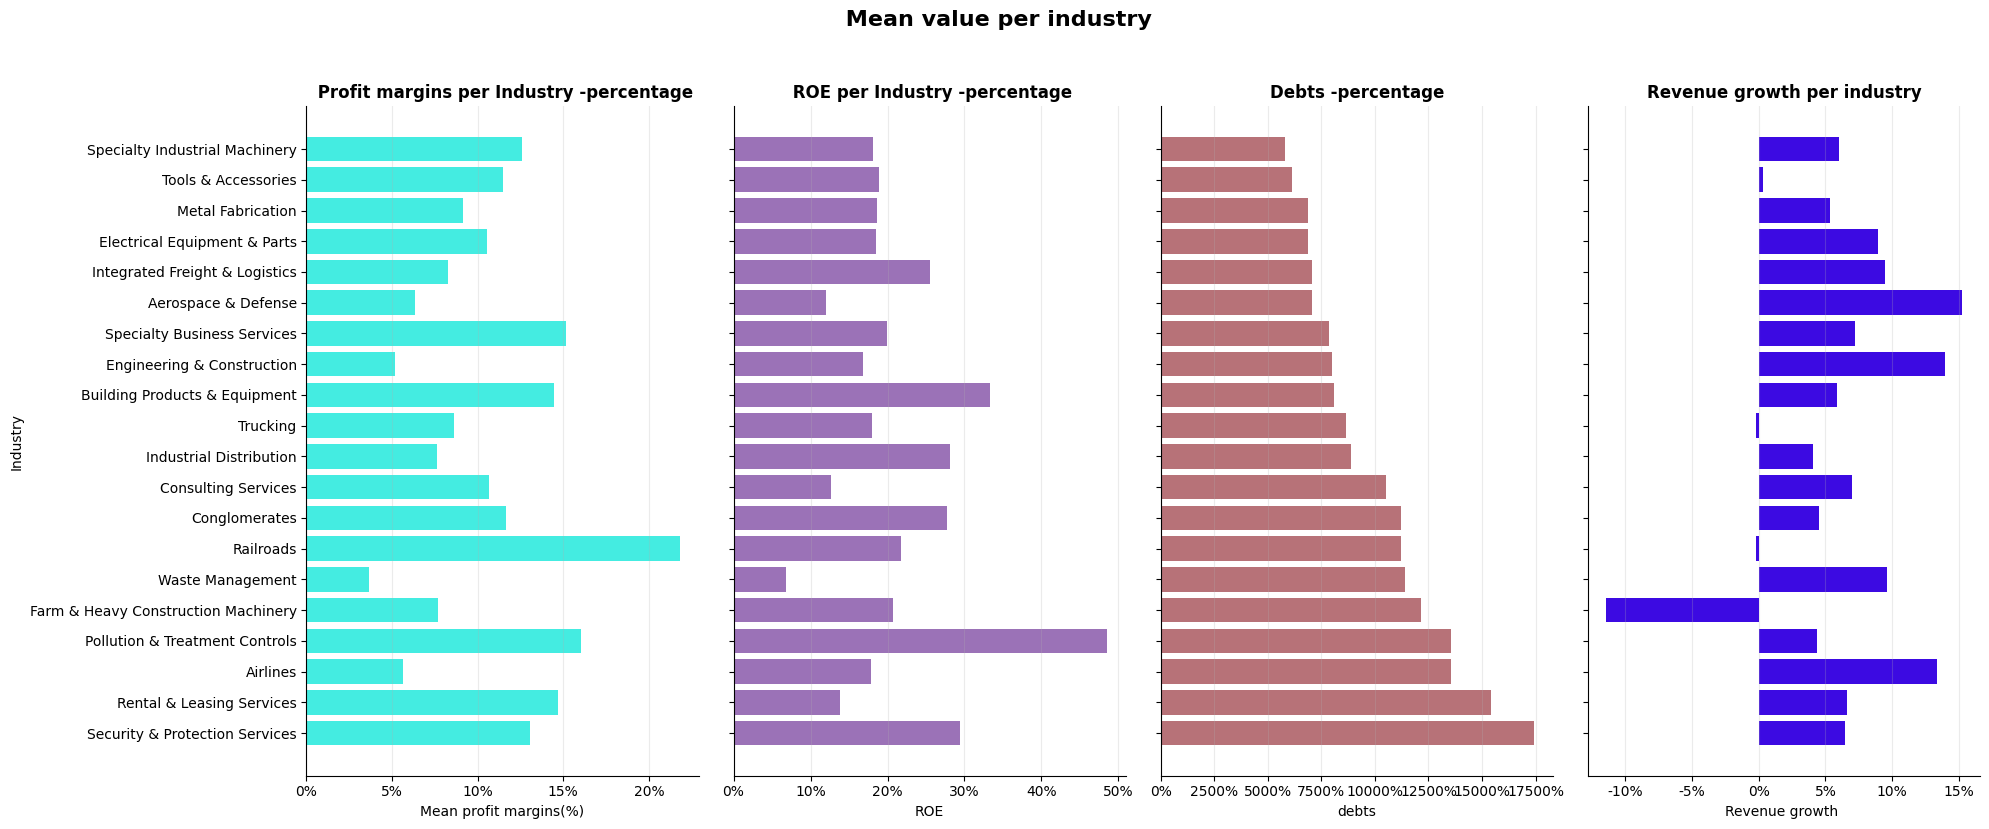

In [681]:


grouped = df_filtered_clean[["industry", "profit_margin_pct", "return_on_equity_pct", "debt_to_equity_pct", "revenue_growth_pct"]].groupby("industry").mean()


grouped["score"] = (
    grouped["profit_margin_pct"] +
    grouped["return_on_equity_pct"] +
    grouped["revenue_growth_pct"] -
    grouped["debt_to_equity_pct"]
)

grouped = grouped.sort_values("score", ascending=True)

# Create one figure with four columns.
fig, ax = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(20, 8),
    sharey=True
)

ax_prof = ax[0]
ax_ROE = ax[1]
ax_debt = ax[2]
ax_rev = ax[3]




#profit_margins
ax_prof.barh(
    grouped.index,
    grouped["profit_margin_pct"],
    color="#44ECE1"
)

ax_prof.set_title(" Profit margins per Industry -percentage",fontweight="bold")
ax_prof.set_xlabel("Mean profit margins(%)")
ax_prof.set_ylabel("Industry")
ax_prof.grid(axis="x", alpha=0.25)
ax_prof.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
clean_spines(ax_prof)

# 2. ROE
ax_ROE.barh(
    grouped.index,
    grouped["return_on_equity_pct"],
    color = "#9B72B7"
)

ax_ROE.set_title(" ROE per Industry -percentage",fontweight="bold")
ax_ROE.set_xlabel("ROE")
ax_ROE.grid(axis="x", alpha=0.25)
ax_ROE.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
clean_spines(ax_ROE)

# 3. debts
ax_debt.barh(grouped.index,
            grouped["debt_to_equity_pct"],
            color ="#B77278"
)
ax_debt.set_title("Debts -percentage",fontweight="bold")
ax_debt.set_xlabel("debts")
ax_debt.grid(axis="x", alpha=0.25)
ax_debt.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
clean_spines(ax_debt)



# 4. Revenue Growth
ax_rev.barh(
    grouped.index,
    grouped["revenue_growth_pct"],
    color ="#3C0AE2"
)

ax_rev.set_title("Revenue growth per industry",fontweight="bold")
ax_rev.set_xlabel("Revenue growth ")
ax_rev.grid(axis="x", alpha=0.25)
ax_rev.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
clean_spines(ax_rev)




fig.suptitle(
    " Mean value per industry",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()
 

## Selected industries 
I choose to select industries that show a good trade-off among the following financial variables:

+ Profit margin: Profit margin indicates the proportion of revenue remaining after all costs are covered, reflecting a company’s financial efficiency.
+ ROE (Return on Equity): Return on Equity (ROE) measures how efficiently a company generates profit from shareholders’ equity. A high ROE indicates a company is capable of generating strong profits with investors’ capital, while a low ROE suggests lower efficiency in using equity to produce earnings.
+ Debt-to-Equity ratio: The Debt-to-Equity ratio compares a company’s total debt to its shareholders’ equity. A high D/E ratio indicates greater reliance on debt financing (higher financial risk), while a low D/E ratio suggests a more conservative capital structure with less dependence on debt.
+ Revenue growth: Revenue growth measures how much a company’s sales increase over a specific period of time.

Companies with high profit margins, high ROE, strong revenue growth, and low debt-to-equity ratios generally have a stronger financial profile and a potential competitive advantage, as they combine profitability, efficiency, growth, and lower financial risk.

I decide to insert into my analysis the four strongest industries:
+ Integrated Freight & Logistcs
+ Buiding Products & Equipment
+ Speciality Industrial Machinary
+ Aerosoace & Difense

I identified these industries  because they exhibit a more balanced financial profile across all variables considered. Both industries combine relatively high profit margins, positive revenue growth, solid ROE levels, and moderate debt exposure.


In [682]:
selected_industries = df_filtered_clean[
    df_filtered_clean['industry'].isin([
        'Industry',
        'Integrated Freight & Logistics',
        'Building Products & Equipment',
         'Specialty Industrial Machinery',
         'Aerospace & Defense'
    ])]

selected_industries.head(40)

,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,...,enterprise_value_b,revenue_b,net_income_b,free_cashflow_b,profit_margin_pct,revenue_growth_pct,earnings_growth_pct,return_on_assets_pct,return_on_equity_pct,debt_to_equity_pct
40,GE,GE Aerospace,Industrials,Aerospace & Defense,217720979456,225490796544,204.130005,203.929993,212.190002,133.990005,...,225.490797,38.701998,6.647000e+00,4.416875e+00,16.940001,14.300001,20.999999,3.271000,27.643999,10415.499878
53,RTX,RTX Corporation,Industrials,Aerospace & Defense,179529449472,215817093120,132.369995,134.470001,135.740005,95.269997,...,215.817093,80.738001,4.774000e+00,5.555375e+00,5.913000,8.500000,4.900000,3.258000,8.125000,6982.099915
97,ETN,"Eaton Corporation, PLC",Industrials,Specialty Industrial Machinery,115779682304,123760476160,295.440002,295.529999,379.989990,255.649994,...,123.760476,24.878000,3.794000e+00,2.847125e+00,15.250000,4.600000,4.300000,7.605000,20.201999,5388.299942
115,UPS,"United Parcel Service, Inc.",Industrials,Integrated Freight & Logistics,99144261632,117674188800,115.099998,116.980003,157.990005,109.400002,...,117.674189,91.069997,5.782000e+00,4.794625e+00,6.349000,1.500000,7.000000,7.106000,33.955002,15321.000671
145,PH,Parker-Hannifin Corporation,Industrials,Specialty Industrial Machinery,80441884672,88758853632,622.099976,624.719971,718.440002,492.709991,...,88.758854,19.907748,3.158499e+00,3.211407e+00,15.865999,-1.600000,38.600001,8.776000,25.852001,6887.500000
150,TT,Trane Technologies plc,Industrials,Building Products & Equipment,78351581184,81684766720,347.140015,349.329987,422.000000,286.320007,...,81.684767,19.838200,2.592600e+00,2.483888e+00,12.944001,10.200000,20.999999,10.950000,36.048001,7192.600250
157,ITW,Illinois Tool Works Inc.,Industrials,Specialty Industrial Machinery,74361200640,80899293184,251.339996,253.360001,279.130005,232.770004,...,80.899293,15.898000,3.488000e+00,2.697625e+00,21.940000,-1.300000,6.600000,17.541000,110.205007,24353.300476
167,GD,General Dynamics Corporation,Industrials,Aerospace & Defense,71832166400,80085581824,263.410004,265.700012,316.899994,239.869995,...,80.085582,47.716000,3.782000e+00,2.304000e+00,7.926000,14.300001,14.100000,5.386000,17.444000,4838.899994
170,NOC,Northrop Grumman Corporation,Industrials,Aerospace & Defense,71034667008,85077499904,490.720001,489.230011,555.570007,418.600006,...,85.077500,41.032999,4.174000e+00,4.060000e+00,10.172000,0.500000,0.000000,7.128000,27.748001,12031.400299
190,EMR,Emerson Electric Company,Industrials,Specialty Industrial Machinery,63782731776,75093729280,113.110001,111.800003,134.850006,96.620003,...,75.093729,17.550000,2.034000e+00,3.876000e+00,13.738000,1.400000,319.899988,4.448000,7.704000,3129.800034


## Step 6 - Bubble chart
Using the filtered dataset from the step 5, create a bubble chart. You decide:
+ what goes on the x-axis 
+ what goes on the y-axis
+ what determines bubble size 
+ what determines bubble color 
Document that 4 choices in a comment before the code, and explain what each encoding is meant to revel. 
Divide the chart into 4 quadrants. Each quadrant represents a combination of the two axis values.

+ x-axis = revenue growth (%)
+ y-axis = earnings growth (%)
+ color = beta
+ size = enterprise value

There is a positive relationship between revenue growth and earnings growth, as revenue growth measures the increase in sales over a given period, while earnings growth measures the increase in net profit over the same period, after deducting costs, taxes, and interest.


In [683]:
#Remove the outliers 

enterprise_low = selected_industries["enterprise_value_b"].quantile(0.05)
enterprise_high = selected_industries["enterprise_value_b"].quantile(0.95)
revenue_low = selected_industries["revenue_growth_pct"].quantile(0.05)
revenue_high = selected_industries["revenue_growth_pct"].quantile(0.95)
earnings_low = selected_industries["earnings_growth_pct"].quantile(0.05)
earnings_high = selected_industries["earnings_growth_pct"].quantile(0.95)
beta_low = selected_industries["beta"].quantile(0.05)
beta_high = selected_industries["beta"].quantile(0.95)


selected_industries_clean = selected_industries[selected_industries["enterprise_value_b"].between(enterprise_low,enterprise_high)&
                                                selected_industries["revenue_growth_pct"].between(revenue_low,revenue_high)&
                                                selected_industries["earnings_growth_pct"].between(earnings_low,earnings_high)&
                                                selected_industries["beta"].between(beta_low,beta_high)]


            

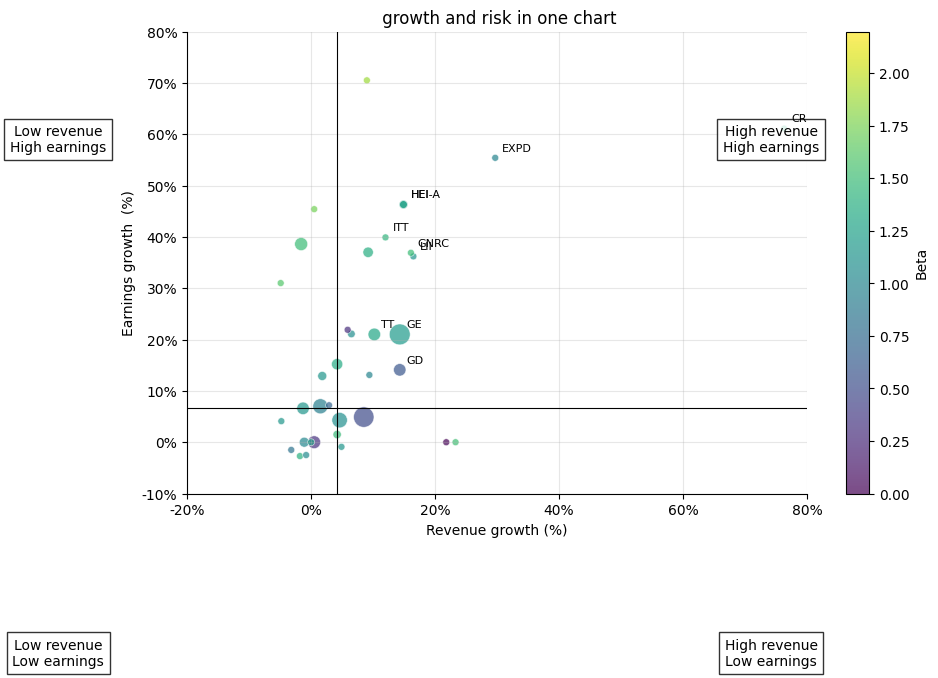

In [684]:




growth_df = selected_industries[
    (selected_industries["enterprise_value_b"] >= 8) &
    (selected_industries["revenue_growth_pct"].between(-50, 100)) &
    (selected_industries["earnings_growth_pct"].between(-80, 100)) &
    (selected_industries["beta"].between(0, 3))
].dropna(subset=["revenue_growth_pct", "earnings_growth_pct", "beta", "enterprise_value_b"]).copy()

fig, ax = plt.subplots(figsize=(10, 6))

sizes = (growth_df["enterprise_value_b"]).clip(lower=25, upper=600)

points = ax.scatter(
    growth_df["revenue_growth_pct"],
    growth_df["earnings_growth_pct"],
    s=sizes,
    c=growth_df["beta"],
    cmap="viridis",
    alpha=0.70,
    edgecolors="white",
    linewidth=0.5
)


x_mid = growth_df["revenue_growth_pct"].median()
y_mid = growth_df["earnings_growth_pct"].median()

ax.axvline(x_mid, color="black", linewidth=0.8)
ax.axhline(y_mid, color="black", linewidth=0.8)

#set the limit of the axixs 
ax.set_xlim(-20, 80)
ax.set_ylim(-10, 80)


# Add quadrant labels.
ax.text(x_mid + 70, y_mid + 50, "High revenue\nHigh earnings", ha="center", fontsize=10,bbox=dict(facecolor="white", alpha=0.8))
ax.text(x_mid + 70, y_mid - 50, "High revenue\nLow earnings",ha="center", fontsize=10,bbox=dict(facecolor="white", alpha=0.8))
ax.text(x_mid - 45, y_mid + 50, "Low revenue\nHigh earnings", ha="center", fontsize=10,bbox=dict(facecolor="white", alpha=0.8))
ax.text(x_mid - 45, y_mid - 50, "Low revenue\nLow earnings", ha="center", fontsize=10, bbox=dict(facecolor="white", alpha=0.8))


# Annotate a few attractive candidates: positive growth, positive margin, beta below 1.5.
candidates_for_labels = growth_df[
    (growth_df["revenue_growth_pct"] > 10) &
    (growth_df["earnings_growth_pct"] > 12) &
    (growth_df["beta"] < 1.8)
].nlargest(10, "enterprise_value_b")

for _, row in candidates_for_labels.iterrows():
    ax.annotate(
        row["symbol"],
        (row["revenue_growth_pct"], row["earnings_growth_pct"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize= 8,
        weight="normal"
    )

ax.set_title(" growth and risk in one chart")
ax.set_xlabel("Revenue growth (%)")
ax.set_ylabel("Earnings growth  (%)")
ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.grid(alpha=0.30)
clean_spines(ax)

cbar = plt.colorbar(points, ax=ax)
cbar.set_label("Beta")

plt.show()

## Step 7
 Choose one quadrant from step 6 and justify your choice in a comment- Filter to the companies in that quadrant. If there are more than 10, keep the top 10 by a dimention you prefer.
 Use the yfinance example seen in class to download the 3 months of daily closing prices.Normalize all series to one  on the first available trading day and plot them on a single chart with a legend identifying each company

In your comment reflet on what you observe in the price chart in relation to the current geopolitical situation, in particular the tensions in the Strait of Hormuz. 
+ Where the companies in this quadrant visibly affected?
+ Do you see a sharp drop, a gradual decline, or no significant impact?
+ Is there any sign of recovery?

In [685]:
# Select companies with:
# - revenue growth above 10%
# - earnings growth above 12%
# - beta below 1.8
# Then keep the top 10 companies by enterprise value.

first_quadrant = growth_df[
    (growth_df["revenue_growth_pct"] > 10) &
    (growth_df["earnings_growth_pct"] > 12) &
    (growth_df["beta"] < 1.8)
].nlargest(10, "enterprise_value_b")
print(first_quadrant)

# I selected companies with strong revenue and earnings growth and relatively moderate risk (beta below 1.8),
# because they may indicate firms with competitive advantages and solid business.
# These firms are located on the first quadrant

    symbol                     company_name       sector  \
40      GE                     GE Aerospace  Industrials   
150     TT           Trane Technologies plc  Industrials   
167     GD     General Dynamics Corporation  Industrials   
346    HEI                Heico Corporation  Industrials   
347  HEI-A                Heico Corporation  Industrials   
483    LII       Lennox International, Inc.  Industrials   
567   EXPD  Expeditors International of Was  Industrials   
719    ITT                         ITT Inc.  Industrials   
883   GNRC           Generac Holdlings Inc.  Industrials   
830     CR                    Crane Company  Industrials   

                           industry    market_cap  enterprise_value  \
40              Aerospace & Defense  217720979456      225490796544   
150   Building Products & Equipment   78351581184       81684766720   
167             Aerospace & Defense   71832166400       80085581824   
346             Aerospace & Defense   31861682176      

[*********************100%***********************]  10 of 10 completed


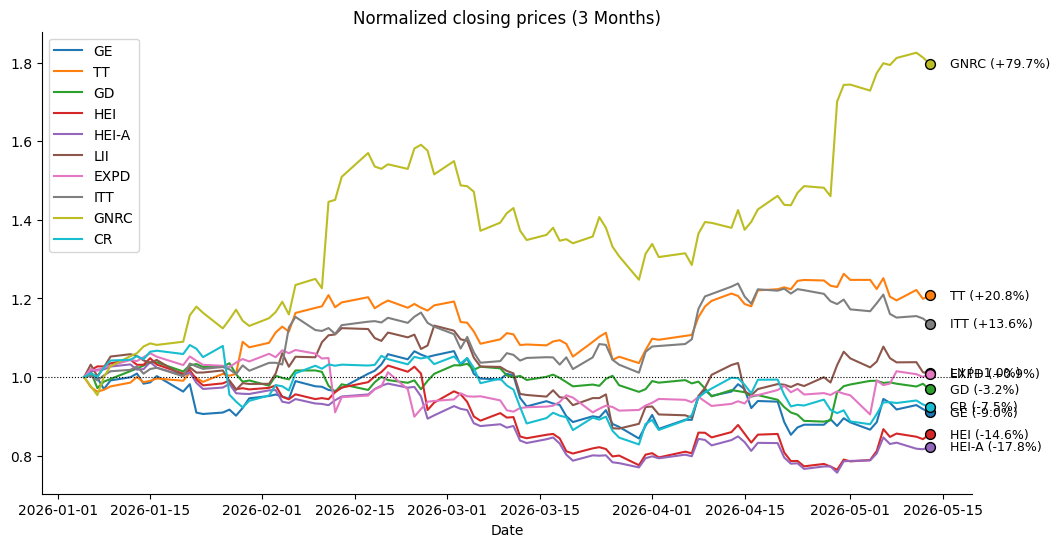

In [686]:
import yfinance as yf

# Extract  symbols from the dataframe
tickers = first_quadrant["symbol"].dropna().tolist()

# Download approximately 3 months of daily stock prices from yfinance (approximated as 90 trading days)
data = yf.download(tickers, period="90d", interval="1d", auto_adjust=True)

# Keep only daily closing prices
closing_prices = data["Close"]

# Normalize all series to 1 on the first available trading day.
# Each value is divided by the first value of the series.
normalized_prices = closing_prices / closing_prices.iloc[0]

fig, ax = plt.subplots(figsize=(12, 6))

# Plot one line for each company
for ticker in tickers:
    # Get the final normalized value
    ticker_final = normalized_prices[ticker].iloc[-1]

    ax.plot(normalized_prices.index, normalized_prices[ticker],linewidth=1.5,label=ticker)

     # Get the last available trading day
    final_date =  normalized_prices.index[-1]

  # Highlight the final point on the chart
    ax.scatter(final_date,ticker_final,edgecolor="black",zorder=5,s=50)

# Compute percentage change since day 0.
# Because the series is normalized to 1, (final - 1) * 100 gives the % gain/loss.
    pct_change = (ticker_final - 1) * 100
    label_text = f"{ticker} ({pct_change:+.1f}%)"

    ax.annotate(label_text,
                xy=(final_date, ticker_final),
                xytext=(15, 0),
                textcoords="offset points",
                va="center",
                fontsize=9
                )


# Remove unnecessary borders for a cleaner style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add a horizontal reference line at 1
ax.axhline(1, color="black", linestyle=":", linewidth=0.8)

# Add chart title and labels
ax.set_title("Normalized closing prices (3 Months)")
ax.set_xlabel("Date")
ax.legend()
plt.show()

Observing the graph and news from Yahoo Finance, some information can be extracted about these companies.

The companies that registered a visible increase and decreare in prices are: GNRC, ITT, TT, HEI and HEI-A

+ *Generic Holdings Inc (GNRC)*:registered high sales and improved profitability driven by strong demand in the Commercial & Industrial segment. The company also benefited from positive earnings revisions and optimistic growth expectations related to energy infrastructure. Observing the chart, a strong upward movement is observed starting on 2026-02-15. Between mid-March and early April, the stock experienced a gradual decline, followed by a recovery in mid-April. In May, the price recorded another strong increase.

+ *ITT Inc*: experienced a sharp increase in its stock price on 2026-02-01. The price then continued to rise at a gradual and moderate pace. From mid-March to early April, there was a slight decline, followed by signs of recovery in mid-April.Yahoo Finance reports that orders, revenue, and earnings rose, driven by broad-based growth and the SPX FLOW acquisition, with improved margins and strong demand across key markets.

+ *Trane Technologies plc (TT)*:the stock reported a moderate increase in prices from 2026-01-01 to 2026-03-01. From mid-March to the beginning of April, there was a gradual decline, and from mid-April until now, there has been a strong rebound.

The companies that showed a decline in prices are: HEI and HEI-A (Heico Corporation).

*HEI*: in recent months, the company has experienced a general negative trend in its stock price. A similar pattern can be observed for *HEI-A*. From the chart, there are currently no clear signs of recovery.

The other companies (GE, GD, LII, EXPD, and CR) exhibited relatively stable trends over the analysis period, with limited volatility and values remaining close to 1 on the normalized scale. From the chart, it can be observed that after 2026-03-01, the stock prices of these companies slightly decreased.



+ *Generic Holdings Inc (GNRC)*. is a US-based energy technology company that designs and manufactures backup power systems, residential and industrial generators, energy storage solutions, and smart energy  products for homes, businesses, and critical infrastructure.

+ *ITT Inc*. is an industrial engineering company that develops components and technical systems for various industrial applications, focusing on efficiency and reliability in industrial markets.

+ *Trane Technologies plc (TT)* is a global industrial company that provides climate control, HVAC, refrigeration, and energy-efficiency solutions for commercial buildings, homes, transportation, and industrial applications, with a strong focus on sustainability and smart building technologies.

+ *HEI* is an aerospace and defense company that produces aircraft components and electronic systems, primarily serving the aviation and defense industries.

**The Strait of Hormuz** is the primary export route for oil produced by Saudi Arabia, the UAE, Kuwait, Qatar, Iraq, Bahrain and Iran. The closure of the Strait of Hormuz mainly affects global energy prices and inflation expectations, with indirecteffects on the selected companies.

+ *Generac Holdings Inc.* (GNRC) may benefit indirectly from electricity instability as it may boost demand for **backup generators** and energy storage systems for residential and industrial use.

+ *ITT Inc.* could experience mixed effects: higher energy and input costs may **increase operating expenses** (negative impact on profit margins), but **strong industrial demand** and infrastructure spending can partially offset these pressures.

+ Trane Technologies (TT) may benefit from rising oil costs, as higher prices tend to accelerate demand for **energy-efficient** and climate control solutions, supporting its sustainability-focused business model.

+ *Heico Corporation* (HEI and HEI-A) in aerospace and defense is largely unaffected directly by energy supply disruptions, although macroeconomic volatility (inflation, interest rates) could indirectly influence performance.


## Step 8 - Compare with an excluded quadrant
Pick one of the three ramaining quadrants from step 6. Apply the same procedure as step 7: take the top 10 companies by the same dimention, download the last 3 months of prices, normalize and plot on a single chart. 
In your comments compare the behavior of this group with the one in step 7. 
Did these companies react differently to the same geopolitical context ?
Where they more resilient, more exposed, or did they follow a similar pattern?

In [687]:
third_quadrant = growth_df[
    (growth_df["revenue_growth_pct"] <= x_mid) &
    (growth_df["earnings_growth_pct"] <= y_mid)
].nlargest(10, "enterprise_value_b")

print(third_quadrant)

# I chose the third quadrant to compare companies in a weaker financial situation.
# The companies in the first quadrant have both positive revenue and earnings growth.
# The companies in the fourth quadrant have both low revenue and earnings growth.

    symbol                     company_name       sector  \
170    NOC     Northrop Grumman Corporation  Industrials   
157    ITW         Illinois Tool Works Inc.  Industrials   
262    CMI                     Cummins Inc.  Industrials   
333     IR              Ingersoll Rand Inc.  Industrials   
373    ROK        Rockwell Automation, Inc.  Industrials   
602   BLDR       Builders FirstSource, Inc.  Industrials   
597   JBHT  J.B. Hunt Transport Services, I  Industrials   
589    CSL  Carlisle Companies Incorporated  Industrials   
605    PNR                     Pentair plc.  Industrials   
635    TXT                     Textron Inc.  Industrials   

                           industry   market_cap  enterprise_value  \
170             Aerospace & Defense  71034667008       85077499904   
157  Specialty Industrial Machinery  74361200640       80899293184   
262  Specialty Industrial Machinery  44736471040       50742681600   
333  Specialty Industrial Machinery  32919791616       3612

[*********************100%***********************]  10 of 10 completed


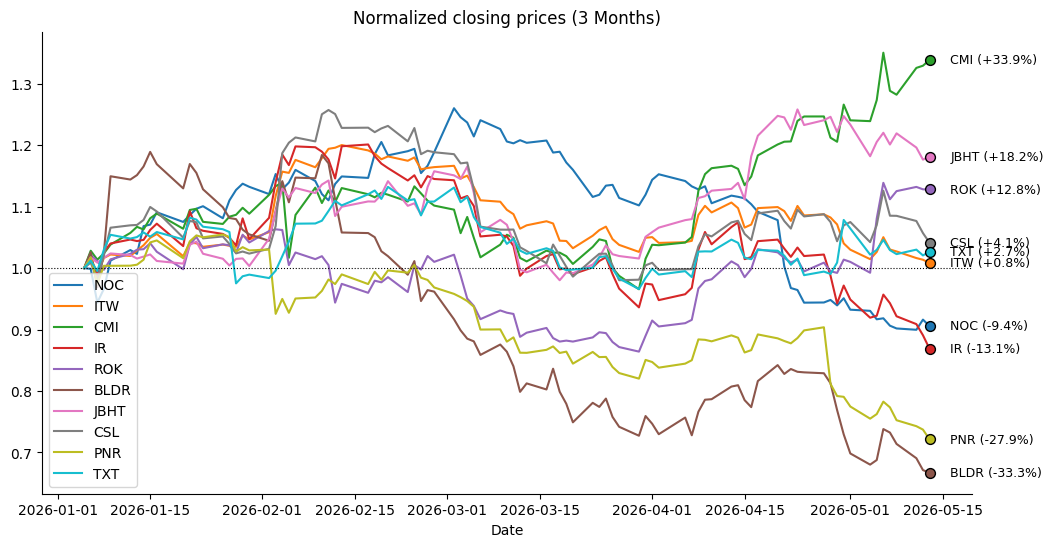

In [688]:
# Extract  symbols from the dataframe
tickers = third_quadrant["symbol"].dropna().tolist()

# Download 3 months of daily stock prices from  yfinance
data = yf.download(tickers, period="90d", interval="1d", auto_adjust=True)

# Keep only daily closing prices
closing_prices = data["Close"]

# Normalize all series to 1 on the first available trading day.
# Each value is divided by the first value of the series.
normalized_prices = closing_prices / closing_prices.iloc[0]

fig, ax = plt.subplots(figsize=(12, 6))

# Plot one line for each company
for ticker in tickers:
    # Get the final normalized value
    ticker_final = normalized_prices[ticker].iloc[-1]

    ax.plot(normalized_prices.index, normalized_prices[ticker],linewidth=1.5,label=ticker)

     # Get the last available trading day
    final_date =  normalized_prices.index[-1]

  # Highlight the final point on the chart
    ax.scatter(final_date,ticker_final,edgecolor="black",zorder=5,s=50)

# Compute percentage change since day 0.
# Because the series is normalized to 1, (final - 1) * 100 gives the % gain/loss.
    pct_change = (ticker_final - 1) * 100
    label_text = f"{ticker} ({pct_change:+.1f}%)"

    ax.annotate(label_text,
                xy=(final_date, ticker_final),
                xytext=(15, 0),
                textcoords="offset points",
                va="center",
                fontsize=9
                )


# Remove unnecessary borders for a cleaner style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add a horizontal reference line at 1
ax.axhline(1, color="black", linestyle=":", linewidth=0.8)

# Add chart title and labels
ax.set_title("Normalized closing prices (3 Months)")
ax.set_xlabel("Date")
ax.legend()
plt.show()